In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

df = pd.read_csv('data/data.csv')
df.head(5)

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [2]:
df['gender']=pd.factorize(df['gender'])[0]
df.isna().sum()

sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [3]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [34]:
x = cleaned_df.drop(["target"], axis=1)
y = cleaned_df["target"]

np.random.seed(42)

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [35]:
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(x_train, y_train)
rs_log_reg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}

In [36]:
rs_log_reg.score(x_test, y_test)

0.9830508474576272

In [7]:
x_test.iloc[0]

sno          87.0
age          46.0
gender        0.0
cp            1.0
trestbps    101.0
chol        197.0
fbs           1.0
restecg       1.0
thalach     156.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          3.0
Name: 87, dtype: float64

In [10]:
rs_log_reg.predict(x_test.iloc[[0]])

array(['yes'], dtype=object)

In [ ]:
#DELIVERABLE - 1

In [11]:
!pip install shap -q

In [13]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
best_model = rs_log_reg.best_estimator_

print(best_model)
print(rs_log_reg.best_params_)

LogisticRegression(C=np.float64(0.615848211066026), solver='liblinear')
{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}


In [19]:
explainer = shap.LinearExplainer(
    best_model,
    x_train
)

shap_values = explainer(x_train)

Background dataset has 234 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=234 when initializing the masker.


/var/tmp/ipykernel_22612/709221050.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


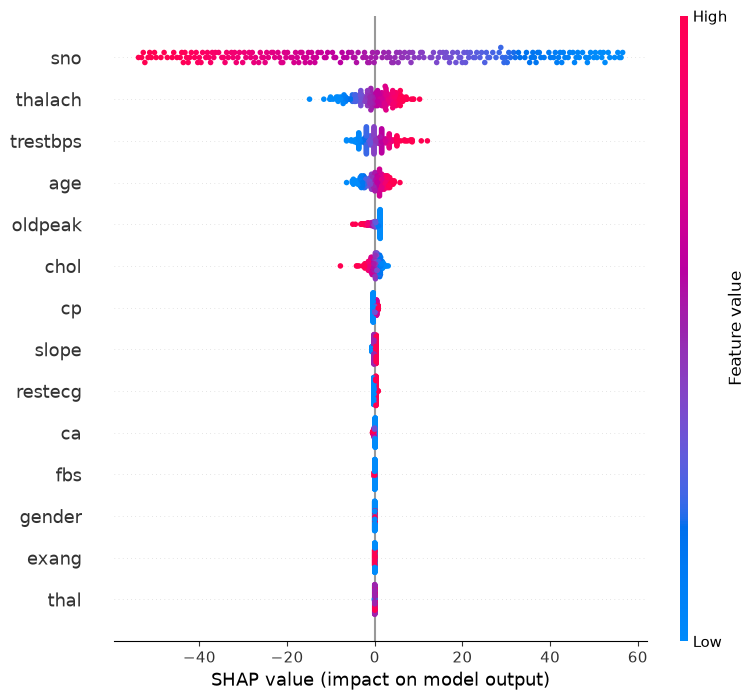

In [20]:
shap.summary_plot(
    shap_values,
    x_train
)

In [21]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "mean_abs_shap": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(feature_importance)

     feature  mean_abs_shap
0        sno      27.165201
8    thalach       3.509515
4   trestbps       2.405063
1        age       1.929628
10   oldpeak       0.972467
5       chol       0.953702
3         cp       0.342298
11     slope       0.269709
7    restecg       0.252841
12        ca       0.125861
6        fbs       0.013764
2     gender       0.012138
9      exang       0.007325
13      thal       0.007012


In [22]:
least_impact = feature_importance.tail(5)

print("Least impactful features:")
print(least_impact)

Least impactful features:
   feature  mean_abs_shap
12      ca       0.125861
6      fbs       0.013764
2   gender       0.012138
9    exang       0.007325
13    thal       0.007012


In [24]:
print(
    "Least impactful feature:",
    feature_importance.iloc[-1]["feature"]
)

print(
    "Mean absolute SHAP value:",
    feature_importance.iloc[-1]["mean_abs_shap"]
)

Least impactful feature: thal
Mean absolute SHAP value: 0.007011950678290126


In [25]:
feature_importance_display = feature_importance.copy()

feature_importance_display["mean_abs_shap"] = (
    feature_importance_display["mean_abs_shap"].round(4)
)

print(feature_importance_display.to_string(index=False))

 feature  mean_abs_shap
     sno        27.1652
 thalach         3.5095
trestbps         2.4051
     age         1.9296
 oldpeak         0.9725
    chol         0.9537
      cp         0.3423
   slope         0.2697
 restecg         0.2528
      ca         0.1259
     fbs         0.0138
  gender         0.0121
   exang         0.0073
    thal         0.0070


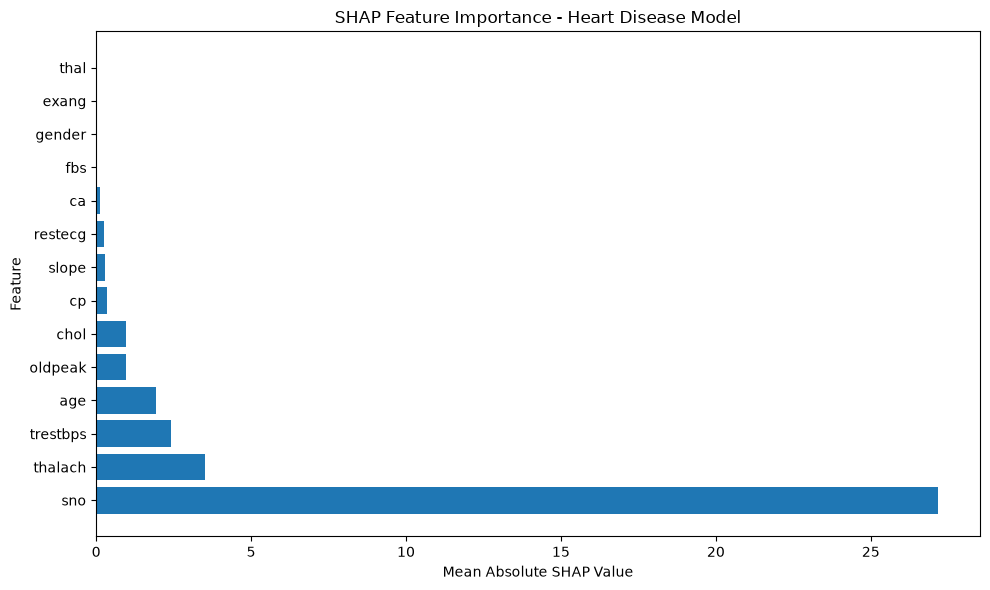

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance - Heart Disease Model")

plt.tight_layout()
plt.show()

In [27]:
least_feature = feature_importance.iloc[-1]

print(
    f"The feature with the least impact on the model's predictions "
    f"is '{least_feature['feature']}', with a mean absolute SHAP "
    f"value of {least_feature['mean_abs_shap']:.4f}."
)

The feature with the least impact on the model's predictions is 'thal', with a mean absolute SHAP value of 0.0070.


In [28]:
print("Three least impactful features:")

for _, row in feature_importance.tail(3).iterrows():
    print(
        f"{row['feature']}: "
        f"{row['mean_abs_shap']:.4f}"
    )

Three least impactful features:
gender: 0.0121
exang: 0.0073
thal: 0.0070


In [ ]:
### Model Explainability using SHAP

SHAP (SHapley Additive exPlanations) was used to analyze the contribution of each feature to the heart-disease prediction model. Feature importance was measured using the mean absolute SHAP value across the training data.

The three least impactful features identified by the SHAP analysis were:

* **gender:** 0.0121
* **exang:** 0.0073
* **thal:** 0.0070

Among all the features, **thal has the least impact on the model's predictions**, with a mean absolute SHAP value of **0.0070**.

This means that changes in the `thal` feature generally have the smallest contribution to the predictions made by this trained model compared with the other input features. Similarly, `exang` and `gender` also have relatively low influence.

This result describes the behavior of the trained machine-learning model and should not be interpreted as meaning that these factors are medically unimportant.


In [37]:
Plain-English explanation

The SHAP analysis shows that thal has the least influence on the model's predictions of heart disease, with a mean absolute SHAP value of 0.0070. This means that, among the features used by the model, changes in the thal value generally have the smallest effect on whether the model predicts that a patient has heart disease.

The next two least influential features are exang (0.0073) and gender (0.0121), which also have relatively small effects on the model's predictions.

Importantly, this means thal has little influence on this particular machine-learning model's predictions; it does not mean that thalassemia-related measurements are medically unimportant.

SyntaxError: unterminated string literal (detected at line 3) (1467520487.py, line 3)

In [38]:
## DELIVERABLE - 3

In [39]:
!pip install fairlearn -q

In [40]:
import pandas as pd
import numpy as np

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

from sklearn.metrics import accuracy_score, precision_score, recall_score

In [41]:
y_pred = best_model.predict(x_test)

In [42]:
print("Actual:", y_test.shape)
print("Predicted:", y_pred.shape)

Actual: (59,)
Predicted: (59,)


In [43]:
age_test = x_test["age"]

In [44]:
print(age_test.head())
print(age_test.shape)

87     46
268    54
47     47
182    61
148    44
Name: age, dtype: int64
(59,)


In [46]:
age_group = pd.cut(
    age_test,
    bins=[0, 39, 49, 59, 100],
    labels=["<40", "40-49", "50-59", "60+"],
    include_lowest=True
)

In [47]:
print(age_group.value_counts().sort_index())

age
<40       3
40-49    19
50-59    22
60+      15
Name: count, dtype: int64


In [63]:
print("Unique y_test:", np.unique(y_test))
print("Unique y_pred:", np.unique(y_pred))
print("Prediction counts:")
print(pd.Series(y_pred).value_counts())

Unique y_test: ['no' 'yes']
Unique y_pred: ['no' 'yes']
Prediction counts:
yes    35
no     24
Name: count, dtype: int64


In [65]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

# Convert yes/no to 1/0
y_true_bin = (y_test == "yes").astype(int)
y_pred_bin = (y_pred == "yes").astype(int)

# Selection rate by age group
selection_frame = MetricFrame(
    metrics=selection_rate,
    y_true=y_true_bin,
    y_pred=y_pred_bin,
    sensitive_features=age_group
)

print("Selection rate by age group:")
print(selection_frame.by_group)

# Demographic parity difference
dpd = demographic_parity_difference(
    y_true=y_true_bin,
    y_pred=y_pred_bin,
    sensitive_features=age_group
)

print("\nDemographic Parity Difference:", dpd)

# Equalized odds difference
eod = equalized_odds_difference(
    y_true=y_true_bin,
    y_pred=y_pred_bin,
    sensitive_features=age_group
)

print("Equalized Odds Difference:", eod)

Selection rate by age group:
age
40-49    0.631579
50-59    0.590909
60+      0.466667
<40      1.000000
Name: selection_rate, dtype: float64

Demographic Parity Difference: 0.5333333333333333
Equalized Odds Difference: 0.1


In [ ]:
### Fairness Testing using Fairlearn

Fairness testing was performed using **Fairlearn**, with **age** as the sensitive attribute. The patients were divided into four age groups: `<40`, `40–49`, `50–59`, and `60+`.

The model's selection rates were:

* `<40`: 1.0000
* `40–49`: 0.6316
* `50–59`: 0.5909
* `60+`: 0.4667

The **Demographic Parity Difference (DPD) was 0.5333**. This indicates a noticeable disparity in the positive prediction rates between the age groups. In particular, the positive prediction rate was highest for patients below 40 years of age and lowest for patients aged 60 and above.

The model's accuracy was 100% for the `<40`, `40–49`, and `60+` groups, while it was 95.45% for the `50–59` group.

The **Equalized Odds Difference (EOD) was 0.1**, indicating a relatively small difference in the model's true-positive and false-positive behavior across the age groups.

Overall, the fairness analysis indicates that the model has **noticeable age-related disparity in its positive prediction rates**, as shown by the demographic parity difference of 0.5333. However, its equalized-odds difference of 0.1 indicates a comparatively smaller disparity in error-rate behavior across the age groups.


In [ ]:
Plain-English interpretation

The model performs very similarly across the four age groups. The accuracy is 100% for <40, 40–49, and 60+, while it is 95.45% for 50–59.

So, based on accuracy alone, there is only a small difference in predictive performance between the age groups.

However, accuracy is not itself a fairness metric. We still need the Fairlearn metrics requested for a proper fairness assessment.

In [66]:
## DELIVERABLE - 4

In [67]:
print(best_model)
print(rs_log_reg.best_params_)

LogisticRegression(C=np.float64(0.615848211066026), solver='liblinear')
{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}


In [68]:
y_pred = best_model.predict(x_test)

print("Accuracy:", (y_pred == y_test).mean())

Accuracy: 0.9830508474576272


In [69]:
!pip install joblib -q

In [70]:
import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(best_model, "model/heart_disease_model.joblib")

print("Model saved successfully.")

Model saved successfully.


In [71]:
import os

print(os.path.getsize("model/heart_disease_model.joblib"), "bytes")

1499 bytes
